In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import RANSACRegressor, LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("beyond_hubble.csv")

In [ ]:
is_cepheid = df.is_cepheid

In [ ]:
Y = df[['variance', 'skew', 'kurt', 'is_cepheid']].values

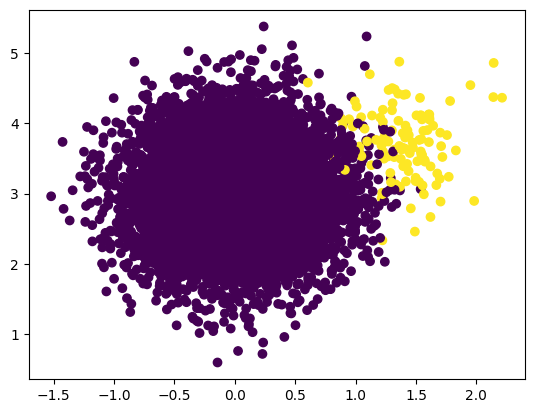

In [ ]:
plt.scatter(Y[:, 1], Y[:, 2], c=Y[:, 3], cmap='viridis')
plt.show()

In [ ]:
X = df[[ 'skew', 'kurt']].values

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42, stratify=is_cepheid)

In [ ]:
kmeans = KMeans(n_clusters=14)
kmeans.fit(X_train)

KMeans(n_clusters=14)

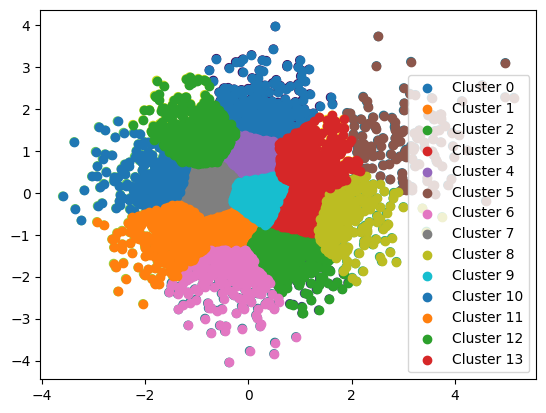

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=kmeans.labels_)
unique_labels = np.unique(kmeans.labels_)

for l in unique_labels:
    subset = X_train[kmeans.labels_ == l]
    plt.scatter(subset[:, 0], subset[:, 1], label=f'Cluster {l}')
plt.legend()
plt.show()

In [ ]:
def cluster_variances(X_train, labels, centers):
    variances = []
    for k in range(len(centers)):
        cluster_points = X_train[labels == k]
        distances = np.linalg.norm(cluster_points - centers[k], axis=1)
        var = np.mean(distances**2)
        variances.append(var)
    return variances

variances = cluster_variances(X_train, kmeans.labels_, kmeans.cluster_centers_)
print("Cluster variances:", variances)
print("max= ", max(variances))
cepheid_label = variances.index(max(variances))
print(cepheid_label)

Cluster variances: [np.float64(0.3886764482044186), np.float64(0.15467536736694204), np.float64(0.3015966424554182), np.float64(0.1599390907833222), np.float64(0.15397176426201256), np.float64(0.9791610462182389), np.float64(0.4332804636894733), np.float64(0.15394017265583984), np.float64(0.44608347704639034), np.float64(0.1346009985682837), np.float64(0.3755296573634479), np.float64(0.33447346203132056), np.float64(0.31830136981477053), np.float64(0.26900392064217643)]
max=  0.9791610462182389
5


In [ ]:
labels_test = kmeans.predict(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

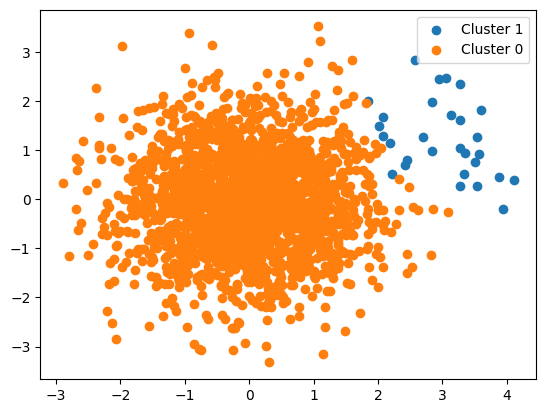

In [ ]:
# plt.scatter(X_test[:, 0], X_test[:, 1], c=[0,1])

subset = X_test[labels_test == cepheid_label]
plt.scatter(subset[:, 0], subset[:, 1], label='Cluster 1')
subset = X_test[labels_test != cepheid_label]
plt.scatter(subset[:, 0], subset[:, 1], label='Cluster 0')

plt.legend()
plt.show


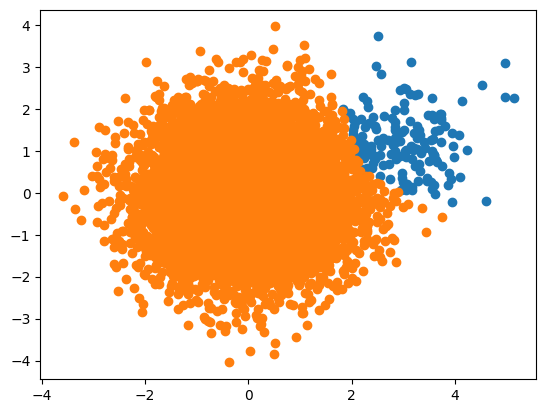

In [ ]:
labels_full = kmeans.predict(X_scaled)
subset = X_scaled[labels_full == cepheid_label]
plt.scatter(subset[:, 0], subset[:, 1], label='Cluster 1')
subset = X_scaled[labels_full != cepheid_label]
plt.scatter(subset[:, 0], subset[:, 1], label='Cluster 0')

plt.show()

In [ ]:
for i in range(len(labels_full)):
    if labels_full[i] == cepheid_label:
        labels_full[i] = 1
    else:
        labels_full[i] = 0

In [ ]:
df['Predicted_is_cepheid'] = labels_full

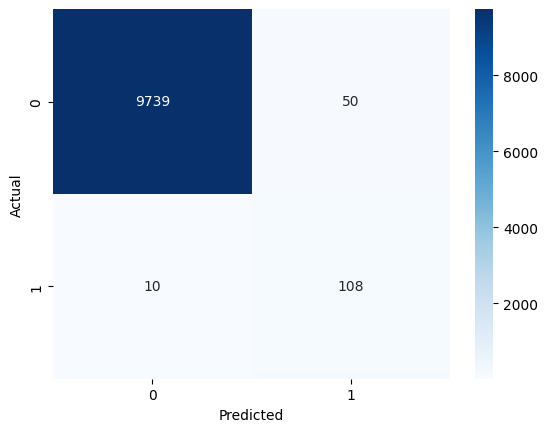

In [ ]:
cm = confusion_matrix(df['is_cepheid'], df['Predicted_is_cepheid'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(df['is_cepheid'], df['Predicted_is_cepheid'], digits = 6))

              precision    recall  f1-score   support

       False   0.998974  0.994892  0.996929      9789
        True   0.683544  0.915254  0.782609       118

    accuracy                       0.993944      9907
   macro avg   0.841259  0.955073  0.889769      9907
weighted avg   0.995217  0.993944  0.994376      9907



In [ ]:
df_mod = df.loc[df.Predicted_is_cepheid == True]

In [ ]:
df_mod['log_period'] = np.log10(df_mod.period)
df_mod['log_dist'] = np.log10(df_mod.dist)

C:\Users\niaji\AppData\Local\Temp\ipykernel_22596\2975635223.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod['log_period'] = np.log10(df_mod.period)
C:\Users\niaji\AppData\Local\Temp\ipykernel_22596\2975635223.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod['log_dist'] = np.log10(df_mod.dist)


In [ ]:
X = df_mod[['log_period', 'apparent_mag']].values
Y = df_mod['log_dist'].values

In [ ]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
Y_train, Y_test = train_test_split(Y, test_size=0.2, random_state=42)

In [ ]:
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    min_samples=50,
    residual_threshold=5.0,
    max_trials=100,
    random_state=42
)

ransac.fit(X_train, Y_train)

RANSACRegressor(estimator=LinearRegression(), min_samples=50, random_state=42,
                residual_threshold=5.0)

In [ ]:
inliers = ransac.inlier_mask_
outliers = ~inliers

In [ ]:
final_estimator = ransac.estimator_
print("Coefficients:", final_estimator.coef_)
print("Intercept:", final_estimator.intercept_)


Coefficients: [0.80704484 0.20148749]
Intercept: -1.5411845275941989


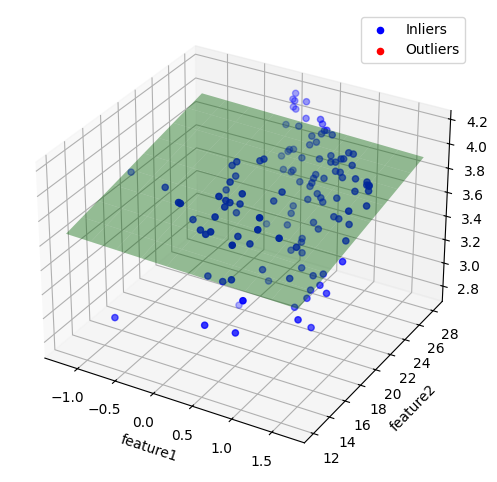

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Plot points
ax.scatter(X_train[inliers, 0], X_train[inliers, 1], Y_train[inliers],
           color="blue", label="Inliers")
ax.scatter(X_train[outliers, 0], X_train[outliers, 1], Y_train[outliers],
           color="red", label="Outliers")

# Plot fitted plane
xx, yy = np.meshgrid(
    np.linspace(X_train[:,0].min(), X_train[:,0].max(), 10),
    np.linspace(X_train[:,1].min(), X_train[:,1].max(), 10)
)
plane = final_estimator.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.plot_surface(xx, yy, plane, alpha=0.4, color='green')

ax.set_xlabel("feature1")
ax.set_ylabel("feature2")
ax.set_zlabel("y")
plt.legend()
plt.show()